# Portfolio Construction

In this notebook, I construct ETF portfolios by optimizing their weight vectors. I explore different optimization objectives and constraints and compare the resulting out-of-sample performance with the benchmark portfolios.

In [17]:
from pathlib import Path

import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "etf_adjusted_close.csv"
RESULTS_DIRECTORY = (
    PROJECT_ROOT / "results"
)

RESULTS_DIRECTORY.mkdir(
    exist_ok=True
)

TRADING_DAYS = 252
ESTIMATION_YEARS = 3
CONFIDENCE_LEVEL = 0.95

prices = pd.read_csv(DATA_PATH, index_col="Date", parse_dates=True)
returns = prices.pct_change(fill_method=None).dropna()

In [18]:
backtest_start = returns.index[
    returns.index >= returns.index.min() + pd.DateOffset(years=ESTIMATION_YEARS)
][0]

backtest_end = returns.index.max()

print("Full data:", returns.index.min(), "to", returns.index.max())
print("Backtest:", backtest_start, "to", backtest_end)

formation_date = backtest_start
estimation_start = formation_date - pd.DateOffset(
    years=ESTIMATION_YEARS
)

estimation_returns = returns.loc[
    (returns.index >= estimation_start)
    & (returns.index < formation_date)
]

Full data: 2007-04-12 00:00:00 to 2020-04-01 00:00:00
Backtest: 2010-04-12 00:00:00 to 2020-04-01 00:00:00


In [19]:
asset_names = estimation_returns.columns
number_of_assets = len(asset_names)

covariance_matrix = estimation_returns.cov().values

weights = cp.Variable(
    number_of_assets,
    name="weights",
)

portfolio_variance = cp.quad_form(weights, covariance_matrix)

## Minimum variance

In [20]:
objective = cp.Minimize(portfolio_variance)

constraints = [cp.sum(weights) == 1, weights >= 0]

problem = cp.Problem(
    objective,
    constraints,
)

problem.solve(solver="CLARABEL")

print("Status:", problem.status)
print("Raw weights:", weights.value)

Status: optimal
Raw weights: [5.52590895e-05 8.38170203e-02 1.27299144e-02 5.58705047e-06
 5.72291989e-06 7.42803731e-01 3.58561396e-06 5.07506811e-03
 8.11031535e-02 3.80782110e-02 3.63092552e-02 1.34921651e-05]


In [21]:
minimum_variance_weights = pd.Series(
    weights.value,
    index=asset_names,
    name="minimum_variance_weight",
)

minimum_variance_weights = (
    minimum_variance_weights
    .clip(lower=0)
)

minimum_variance_weights /= (
    minimum_variance_weights.sum()
)

minimum_variance_weights.sort_values(
    ascending=False
).head(3).round(4)

IEF    0.7428
QQQ    0.0838
HYG    0.0811
Name: minimum_variance_weight, dtype: float64

In [22]:
daily_variance = (
    minimum_variance_weights.values
    @ covariance_matrix
    @ minimum_variance_weights.values
)

daily_volatility = np.sqrt(daily_variance)

annualized_volatility = (
    daily_volatility * np.sqrt(TRADING_DAYS)
)

estimated_portfolio_returns = (
    estimation_returns
    @ minimum_variance_weights
)

number_of_estimation_days = len(
    estimated_portfolio_returns
)

estimated_annualized_return = (
    (1 + estimated_portfolio_returns).prod()
    ** (
        TRADING_DAYS
        / number_of_estimation_days
    )
    - 1
)

print("Daily volatility:", daily_volatility)
print("Annualized volatility:", annualized_volatility)
print("Estimated annualized return:", estimated_annualized_return)

Daily volatility: 0.0040218069834612406
Annualized volatility: 0.06384420659604782
Estimated annualized return: 0.073793559551383


### Single-Period Minimum-Variance Portfolio

The first minimum-variance portfolio is formed on April 12, 2010 using daily ETF returns from April 12, 2007 through April 9, 2010. The optimization problem is

$$
\begin{aligned}
\min_w \quad & w^\top \Sigma w \\
\text{subject to} \quad
& \mathbf{1}^\top w = 1, \\
& w \geq 0,
\end{aligned}
$$

where $\Sigma$ is the sample covariance matrix estimated from the preceding three years of daily returns. The constraints require the portfolio to be fully invested and prohibit short selling.

The solver returned an optimal solution. The portfolio allocates approximately 74.28% to IEF, 8.38% to QQQ, 8.11% to HYG, 3.81% to GLD, and 3.63% to DBC. The remaining assets receive small weights.

This allocation is highly concentrated in IEF, an intermediate-term U.S. Treasury ETF. During the estimation period, IEF provided relatively low volatility and favorable diversification against the riskier equity and credit assets. The nonzero allocations to QQQ, HYG, GLD, and DBC suggest that their covariance relationships with IEF provide additional diversification, even though some of these assets have higher standalone volatility.

The estimated daily volatility of the optimized portfolio is approximately 0.40%, corresponding to an annualized volatility of 6.38%. Its estimated compounded annualized return over the in-sample estimation period is approximately 7.38%.

The strong concentration in IEF also illustrates an important limitation of unconstrained minimum-variance optimization: minimizing estimated variance alone can produce concentrated portfolios. Later models will examine whether maximum-weight constraints, alternative risk measures, and return requirements produce more diversified and economically useful allocations.

For next steps, minimum-variance model is used on 2010-2020 backtest data, and compared to the benchmark stats later. 

In [23]:
def solve_minimum_variance(estimation_returns):

    asset_names = estimation_returns.columns
    number_of_assets = len(asset_names)

    covariance_matrix = estimation_returns.cov().values

    weights = cp.Variable(
        number_of_assets,
        name="weights",
    )

    portfolio_variance = cp.quad_form(weights, covariance_matrix)

    objective = cp.Minimize(portfolio_variance)

    constraints = [cp.sum(weights) == 1, weights >= 0]

    problem = cp.Problem(
        objective,
        constraints,
    )

    problem.solve(solver="CLARABEL")

    return weights.value

In [24]:
backtest_returns = returns.loc[
    backtest_start:backtest_end
]

formation_dates = (
    backtest_returns
    .groupby(backtest_returns.index.to_period("M"))
    .head(1)
    .index
)

weights_history = pd.DataFrame(
    index=formation_dates,
    columns=returns.columns,
    dtype=float,
)

for formation_date in formation_dates:
    estimation_start = formation_date - pd.DateOffset(
        years=ESTIMATION_YEARS
    )

    estimation_returns = returns.loc[
        (returns.index >= estimation_start)
        & (returns.index < formation_date)
    ]

    weight = solve_minimum_variance(estimation_returns)
    weights_history.loc[formation_date] = weight

#print(weights_history .head(5))
#i have weight now. i need to construct portfolio. 
#in this problem, expectation is not considered as objective, so only need to calculate variance. 

In [25]:
realized_return_segments = []

for i, formation_date in enumerate(formation_dates):

    initial_weights = weights_history.loc[
        formation_date
    ]

    if i < len(formation_dates) - 1:
        next_formation_date = formation_dates[i + 1]

        holding_returns = returns.loc[
            (returns.index >= formation_date)
            & (returns.index < next_formation_date)
        ]

    else:
        holding_returns = returns.loc[
            (returns.index >= formation_date)
            & (returns.index <= backtest_end)
        ]

    asset_growth = (
        1 + holding_returns
    ).cumprod()

    portfolio_wealth = (
        asset_growth
        .mul(initial_weights, axis="columns")
        .sum(axis=1)
    )

    portfolio_returns = portfolio_wealth.pct_change()

    portfolio_returns.iloc[0] = (
        portfolio_wealth.iloc[0] - 1
    )

    realized_return_segments.append(
        portfolio_returns
    )

gmv_returns = pd.concat(
    realized_return_segments
)

gmv_returns.name = "GMV"

#daily return of minimum variance portfolio

In [26]:
gmv_wealth = (
    1 + gmv_returns
).cumprod()

gmv_wealth.name = "GMV"

number_of_days = len(gmv_returns)

gmv_cagr = (
    gmv_wealth.iloc[-1]
    ** (TRADING_DAYS / number_of_days)
    - 1
)

gmv_annualized_variance = (
    gmv_returns.var()
    * TRADING_DAYS
)

gmv_annualized_volatility = (
    gmv_returns.std()
    * np.sqrt(TRADING_DAYS)
)

print("Final wealth:", gmv_wealth.iloc[-1])
print("CAGR:", gmv_cagr)
print("Annualized variance:", gmv_annualized_variance)
print("Annualized volatility:", gmv_annualized_volatility)

Final wealth: 1.635433557696162
CAGR: 0.05058531613175332
Annualized variance: 0.0018741388098715483
Annualized volatility: 0.04329132488006747


In [27]:
print("Missing values:", gmv_returns.isna().sum())
print("Duplicate dates:", gmv_returns.index.duplicated().sum())
print(
    "Matches backtest dates:",
    gmv_returns.index.equals(backtest_returns.index)
)

Missing values: 0
Duplicate dates: 0
Matches backtest dates: True


In [28]:
comparison_returns = pd.concat(
    [
        gmv_returns,
        returns.loc[
            gmv_returns.index,
            "SPY",
        ].rename("SPY"),
    ],
    axis=1,
)

print(comparison_returns.head())
print(comparison_returns.tail())
print(comparison_returns.isna().sum())

comparison_wealth = (
    1 + comparison_returns
).cumprod()

                 GMV       SPY
Date                          
2010-04-12  0.001915  0.001589
2010-04-13  0.002136  0.000752
2010-04-14  0.000030  0.011349
2010-04-15  0.002229  0.000825
2010-04-16  0.001164 -0.015912
                 GMV       SPY
Date                          
2020-03-26  0.021316  0.058390
2020-03-27  0.005128 -0.029786
2020-03-30  0.005068  0.032476
2020-03-31 -0.002720 -0.014905
2020-04-01 -0.006592 -0.045005
GMV    0
SPY    0
dtype: int64


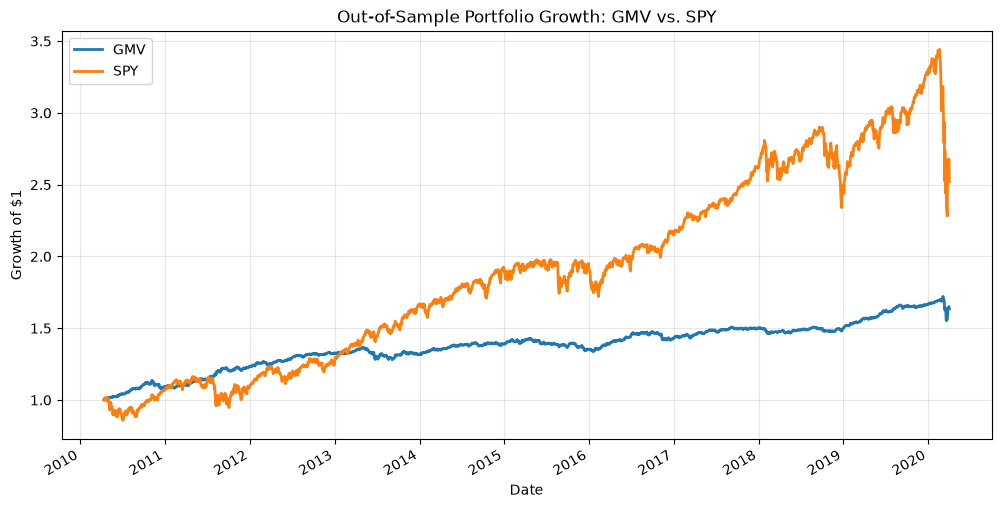

In [29]:
fig, ax = plt.subplots(
    figsize=(12, 6)
)

comparison_wealth.plot(
    ax=ax,
    linewidth=2,
)

ax.set_title(
    "Out-of-Sample Portfolio Growth: GMV vs. SPY"
)

ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.grid(alpha=0.3)

plt.show()

In [30]:
def calculate_performance_metrics(
    portfolio_returns,
    trading_days=252,
):
    wealth = (
        1 + portfolio_returns
    ).cumprod()

    number_of_days = len(
        portfolio_returns
    )

    cagr = (
        wealth.iloc[-1]
        ** (trading_days / number_of_days)
        - 1
    )

    annualized_volatility = (
        portfolio_returns.std()
        * np.sqrt(trading_days)
    )

    sharpe_ratio = (
        portfolio_returns.mean()
        / portfolio_returns.std()
        * np.sqrt(trading_days)
    )

    running_maximum = wealth.cummax()

    drawdown = (
        wealth / running_maximum
        - 1
    )

    maximum_drawdown = drawdown.min()

    return pd.Series({
        "Final Wealth": wealth.iloc[-1],
        "CAGR": cagr,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown,
    })

In [31]:
performance_comparison = (
    comparison_returns
    .apply(calculate_performance_metrics)
    .T
)

performance_comparison

,Final Wealth,CAGR,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
GMV,1.635434,0.050585,0.043291,1.161665,-0.098190
SPY,2.519200,0.097120,0.169469,0.632206,-0.337173


### Out-of-Sample Performance: GMV versus SPY

The rolling global minimum-variance portfolio produced a final wealth of
1.64 and a compounded annual growth rate of 5.06%, compared with a final
wealth of 2.52 and a CAGR of 9.71% for SPY. Therefore, SPY delivered
substantially higher absolute returns over the backtest period.

However, the GMV portfolio achieved its intended risk-reduction objective.
Its annualized volatility was only 4.33%, compared with 16.95% for SPY.
Its maximum drawdown was also substantially smaller, at 9.82% versus
33.72% for SPY.

Assuming a zero risk-free rate, the GMV portfolio achieved a Sharpe ratio
of 1.16, compared with 0.63 for SPY. Thus, although the GMV strategy
sacrificed absolute return, it generated substantially better performance
per unit of realized volatility.

These results illustrate the central trade-off of minimum-variance
optimization. The strategy is not designed to maximize wealth, and its
conservative allocation may underperform equities during a prolonged bull
market. Nevertheless, it may be attractive to highly risk-averse investors
because of its lower volatility and substantially smaller drawdowns.

#### Performance Metrics

Notes for metrics:

- **Compound Annual Growth Rate (CAGR)** converts the total compounded
  return into an equivalent annual growth rate:

  $$
  \operatorname{CAGR}
  =
  V_T^{252/T}-1,
  $$

  where $T$ is the number of daily return observations and 252 is the
  assumed number of trading days per year. CAGR describes the constant
  annual return that would produce the same terminal wealth.


- **Sharpe Ratio** measures average excess return per unit of volatility:

  $$
  \operatorname{Sharpe}
  =
  \frac{\bar r_{\mathrm{daily}}-r_{f,\mathrm{daily}}}
       {\sigma_{\mathrm{daily}}}
  \sqrt{252}.
  $$

  In the current calculation, the risk-free rate is assumed to be zero, so
  the numerator is the average daily portfolio return. A higher Sharpe
  ratio indicates better realized return relative to the volatility
  incurred. Because the current calculation assumes a zero risk-free rate,
  the reported values should be interpreted as preliminary risk-adjusted
  performance measures.

In [32]:
weights_history.to_csv(
    RESULTS_DIRECTORY
    / "gmv_weights_history.csv",
    index_label="Date",
)

gmv_returns.to_frame().to_csv(
    RESULTS_DIRECTORY
    / "gmv_daily_returns.csv",
    index_label="Date",
)